In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from random import randrange
import warnings
from scipy import linalg    
import seaborn as sns
from scipy.stats import linregress
from scipy.spatial import Delaunay
from collections import defaultdict
warnings.filterwarnings('ignore')

datadir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/Trajectories/"
plotsdir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/Plots/"
cmap = plt.cm.get_cmap('BuPu')
clrs=["#c7e9b4","#7fcdbb","#41b6c4","#1d91c0","#225ea8","#0c2c84","#c7e9b4","#7fcdbb","#41b6c4","#1d91c0","#225ea8","#0c2c84"]
clrs2=["#b59837","#fc8d59","#d7301f","#6f0606","#4575b4","#313695","#313695","#4575b4","#91bfdb","#313695","#4575b4","#313695","#fef0d9","#fdcc8a","#fc8d59","#d7301f","#4575b4","#313695","#313695","#4575b4","#91bfdb","#313695","#4575b4","#313695"]
clrs3=["#313695","#623CA2","#B546CE"]

 Defining our basis functions

$L_k(r)$ Laguerre polynomials
The closed form is

$L_{n}(r)=\sum _{k=0}^{n}{\binom {n}{k}}{\frac {(-1)^{k}}{k!}}r^{k}.$

We want ours to -> 0 at large $r$ so we modulate by an exponential
$\phi_{n}(r)=L_{n}(r)e^{-r}$


Laguerre polynomials have the property that $rL'_{n}(r) = nL_{n}(r)-nL_{n-1}(r)$

In [2]:
# outputs vector of size NumBasisFunctions
def laguerre_polynomialsExp(r,NumBasisFunctions,r_mod):
    # Initialize Laguerre*exp(-r) and their derivatives
    L_exp = [np.exp(-r/r_mod), (1 - r) * np.exp(-r/r_mod)]
    #dL_exp = [-np.exp(-r/r_mod), (r - 2) * np.exp(-r/r_mod)]

    # Recursively build L_k(r) * exp(-r)
    L_plain = [1.0, 1 - r]  # plain Laguerre polynomials L_k(r)

    for k in range(2, NumBasisFunctions):
        # Compute next Laguerre polynomial
        Lk = ((2*k - 1 - r) * L_plain[k-1] - (k - 1) * L_plain[k-2]) / k
        L_plain.append(Lk)

        # Multiply by exp(-r)
        Lk_exp = Lk * np.exp(-r/r_mod)
        L_exp.append(Lk_exp)

        # Compute the derivative of L_k(r) * exp(-r)
        # Dlk = -Lk_exp*np.exp(-r/r_mod) + np.exp(-r/r_mod) * (1/r)* (k*Lk-k*L_plain[k-1])
        # dL_exp.append(Dlk)

    #print(np.shape(np.reshape(L_exp,5)))
    return L_exp #, dL_exp

Simulation definitions:

In [3]:
def parse_lammps_xyz(filename):
    data = []
    with open(filename, 'r') as file:
        while True:
            line = file.readline()
            if not line:
                break  # EOF
            
            if "ITEM: TIMESTEP" in line:
                timestep = int(file.readline().strip())
                file.readline()  # Skip "ITEM: NUMBER OF ATOMS"
                num_atoms = int(file.readline().strip())
                file.readline()  # Skip "ITEM: BOX BOUNDS ..."
                file.readline()
                file.readline()
                file.readline()
                file.readline()  # Skip "ITEM: ATOMS id type x y z"
                
                for _ in range(num_atoms):
                    atom_line = file.readline()
                    if not atom_line:
                        break  # Unexpected EOF
                    parts = atom_line.strip().split()
                    atom_id, atom_type = int(parts[0]), int(parts[1])
                    x, y, z = map(float, parts[2:5])
                    data.append({
                        "timestep": timestep,
                        "id": atom_id,
                        "type": atom_type,
                        "x": x,
                        "y": y,
                        "z": z
                    })

    df = pd.DataFrame(data)
    return df

# Unwrapping the trajectories
# The function unwrap_trajectories takes a DataFrame with atom trajectories and unwraps them based on periodic boundary conditions.

def unwrap_trajectories(df, box_length_x, box_length_y):
    # Sort the DataFrame by atom ID and timestep
    df = df.sort_values(by=["id", "timestep"]).copy()

    # Group by atom ID
    unwrapped_x = []
    unwrapped_y = []

    for atom_id, group in df.groupby("id"):
        group = group.sort_values(by="timestep").copy()
        x = group["x"].values
        y = group["y"].values
        timesteps = group["timestep"].values
        if x[0]<0:
            unwrappedX = [x[0]+box_length_x]
        elif x[0]>box_length_x:
            unwrappedX = [x[0]-box_length_x]
        else:
            unwrappedX = [x[0]]
        if y[0]<0:
            unwrappedY = [y[0]+box_length_y]
        elif y[0]>box_length_y:
            unwrappedY = [y[0]-box_length_y]
        else:
            unwrappedY = [y[0]]
        
        shiftX = 0
        shiftY = 0

        for i in range(1, len(x)):
            dx = x[i] - x[i - 1]
            dy = y[i] - y[i - 1]
            if dx > box_length_x / 2:
                shiftX -= box_length_x
            if dy > box_length_y / 2:
                shiftY -= box_length_y
            elif dx < -box_length_x / 2:
                shiftX += box_length_x
            elif dy < -box_length_y / 2:
                shiftY += box_length_y
            unwrappedX.append(x[i] + shiftX)
            unwrappedY.append(y[i] + shiftY)

        unwrapped_x.extend(unwrappedX)
        unwrapped_y.extend(unwrappedY)

    df["x_unwrapped"] = unwrapped_x
    df["y_unwrapped"] = unwrapped_y
    return df

# Function to write positions to .xyz file
def write_xyz(f, positions, step,box_length):
    #with open(f, 'a') as f:
    f.write("ITEM: TIMESTEP\n")
    f.write(f"{step}\n")
    f.write("ITEM: NUMBER OF ATOMS\n")
    f.write(f"{len(positions)}\n")
    # Write box dimensions (optional)
    f.write("ITEM: BOX BOUNDS pp pp pp\n")
    f.write(f"{-box_length/2} {box_length/2}\n")
    f.write(f"{-box_length/2} {box_length/2}\n")
    f.write(f"0.0 0.1\n")
    f.write("ITEM: ATOMS id type x y z\n")
    i=0
    for pos in positions:
        i+=1
        f.write(f"{i} 1 {pos[0]} {pos[1]} 0.0\n") 
        #f.write(f"1 {pos[0]} {pos[1]} 0.0\n")  # Assuming particles are Argon atoms
# Function to compute harmonic trap force
def harmonic_force(positions, kappa, center): 

    displacement = positions - center
    return -kappa * displacement
def compute_lj_forces(positions, box_size, epsilon, sigma, rcut):
    num_particles = len(positions)
    forces = np.zeros_like(positions)
    rcut2 = rcut ** 2
    sigma6 = sigma ** 6
    sigma12 = sigma6 ** 2
    force_scalar=0
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            # Minimum image convention
            rij = positions[i] - positions[j]
            rij -= box_size * np.round(rij / box_size)
            r2 = np.dot(rij, rij)
            
            if r2 < rcut2:
                inv_r2 = 1.0 / r2
                inv_r6 = inv_r2 ** 3
                inv_r12 = inv_r6 ** 2
                inv_r13 = (1/np.sqrt(r2))*inv_r12
                inv_r7 = (1/np.sqrt(r2))*inv_r6
                force_scalar = 48 * epsilon * (sigma12 * inv_r13 - 0.5 * sigma6 * inv_r7)
                    #24 * epsilon * inv_r2 * inv_r6 * (2 * sigma12 * inv_r6 - sigma6)
                force_vec = force_scalar * (rij/np.sqrt(r2))
                forces[i] += force_vec
                forces[j] -= force_vec
        #print('np.shape(force)',forces)
    return forces, force_scalar

def compute_soft_lj_forces(positions, box_size, epsilon, sigma, rcut, lambda_param):
    n,alpha_lj=1,0.5
    num_particles = len(positions)
    forces = np.zeros_like(positions)
    rcut2 = rcut ** 2
    lam_pow_n = lambda_param ** n
    const_factor = 4 * epsilon * lam_pow_n
    dEdr = 0.0
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            rij = positions[i] - positions[j]
            rij -= box_size * np.round(rij / box_size)  # Periodic BC
            r2 = np.dot(rij, rij)

            if r2 < rcut2:
                r = np.sqrt(r2)
                r6 = (r / sigma) ** 6
                A = alpha_lj * (1 - lambda_param)**2 + r6
                dAdr = 6 * (r / sigma)**5 / sigma
                dEdr = const_factor * (-2 / A**3 + 1 / A**2) * dAdr
                force_vec = -dEdr * (rij / r)
                forces[i] += force_vec
                forces[j] -= force_vec

    return forces, -dEdr

def soft_lj_force(r, epsilon, sigma, rcut, lambda_param):
    n = 1
    alpha_lj = 0.5
    dEdr = 0
    """Compute scalar magnitude of soft LJ/cut force for distance r."""
    if r >= rcut or r <= 1e-12:
        return 0.0

    lam_pow_n = lambda_param ** n
    r_over_sigma = r / sigma
    r6 = r_over_sigma ** 6
    A = alpha_lj * (1 - lambda_param)**2 + r6
    dAdr = (6 * r**5) / (sigma**6)

    prefactor = 4 * epsilon * lam_pow_n
    dEdr = prefactor * (2 / A**3 - 1 / A**2) * dAdr

    return -dEdr

def lj_force(r, epsilon, sigma, rcut):
    #n = 1
    #alpha_lj = 0.5
    """Compute scalar magnitude of soft LJ/cut force for distance r."""
    if r >= rcut or r <= 1e-12:
        return 0.0

    #lam_pow_n = lambda_param ** n
    r_over_sigma = r / sigma
    r6 = r_over_sigma ** 6
    A = r6
    dAdr = (6 * r**5) / (sigma**6)
    prefactor = 4 * epsilon * 1
    dEdr = prefactor * (2 / A**3 - 1 / A**2) * dAdr

    print('prefactor',prefactor)
    print('dAdr',dAdr)
    print('(2 / A**3 - 1 / A**2)',(2 / A**3 - 1 / A**2))

    return -dEdr



Simulation itself:

In [49]:
def OD_MD_SimulationLJPairs(num_particles, box_size, kappa, temperature, gamma, dt,
                     num_steps0, equilibration_steps, frame, use_harmonic_trap,
                     name, center, epsilon, sigma, rcut,lambda_param):
    # Initialize particle positions randomly within the box
    positions = np.random.uniform(-box_size / 10, box_size / 10, size=(num_particles, 2)) #
    #adding positions and making sure no overlap
    #start particles in a grid at the center of the box
    # for i in range(num_particles):
    #     positions[i][0] = (i % 5) * (box_size / 30) - box_size / 30
    #     positions[i][1] = (i // 5) * (box_size / 30) - box_size / 30
    # if num_particles > 2:
    #     for i in range(num_particles):
    #         for j in range(i):
    #             while np.linalg.norm(positions[i] - positions[j]) < (sigma+0.1):
    #                 positions[i] = np.random.uniform(-box_size / 2, box_size / 2, size=(2,))
    #print(positions)
    #positions = np.array([np.array([0, sigma+0.1]),np.array([0,0])])
    #print(positions)

    rng = np.random.default_rng()
    num_steps = num_steps0 + equilibration_steps
    min_ljForce = 0
    for step in range(num_steps):
        if step % 1000 == 0:
            print(f"Step {step}/{num_steps}")
        noise = rng.normal(0, np.sqrt(2 * temperature * gamma / dt), size=(num_particles, 2))
        #noise = rng.normal(0, np.sqrt(2 * temperature * dt / gamma), size=(num_particles, 2))
        # Compute LJ forces
        
        lj_force, scalarFLJ = compute_soft_lj_forces(positions, box_size, epsilon, sigma, rcut, lambda_param) #compute_lj_forces(positions, box_size, epsilon, sigma, rcut)
        if scalarFLJ < min_ljForce:
            min_ljForce = scalarFLJ
        #print('np.shape(lj_force)',np.shape(lj_force))
        if use_harmonic_trap:
            trap_force = harmonic_force(positions, kappa, center)
        else:
            trap_force = 0
        if step > equilibration_steps:
            trap_force = 0
            
        # Update positions
        positions += (lj_force + trap_force + noise) * dt / gamma

        # Apply periodic boundary conditions
        positions = (positions + box_size / 2) % box_size - box_size / 2

        if step == 0:
            f = open("/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/Trajectories/" + name, 'w')

        if step % frame == 0 and step > equilibration_steps:
            f = open("/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/Trajectories/" + name, 'a')
            write_xyz(f, positions, step,box_size)

        if step == num_steps - 1:
            f.close()
            print("Simulation completed. Output written to " + name)
            print("Minimum force " + str(min_ljForce)+"for params eps"+str(epsilon)+" sig"+str(sigma)+" rc"+str(rcut))

Pairwise force inference:

In [5]:
def check_cs(df_atoms, Bm05,NumBasisFunctions,L_x,L_y,r_mod):
    # Initialize a matrix to store the time-averaged product of c_alpha and c_beta
    timesteps = df_atoms['timestep'].unique()
    #D = NumBasisFunctions
    df_atoms = df_atoms.sort_values(by=["id", "timestep"]).copy()
    #B_accum = np.zeros((D, D))
    c_alpha_beta_sum = np.zeros((NumBasisFunctions, NumBasisFunctions))
    NumAtoms = np.max(df_atoms.id)
    count = 0
    for t in timesteps:
        df_t = df_atoms[df_atoms['timestep'] == t]
        if len(df_t) != NumAtoms:
            print(f"Skipping timestep {t} due to incomplete data.")
            continue  # skip incomplete timesteps
        coords = df_t.sort_values('id')[['x', 'y']].values  # ensure ordered by id
        for i in range(NumAtoms):
            for j in range(i+1,NumAtoms):
                dx = coords[j, 0] - coords[i, 0] ## dx direction is towards atom j
                dy = coords[j, 1] - coords[i, 1]
                dx = dx - L_x * np.round(dx / L_x)
                dy = dy - L_y * np.round(dy / L_y)
                rij = np.sqrt(dx**2 + dy**2)
                count += 1
                b = laguerre_polynomialsExp(rij,NumBasisFunctions,r_mod)
                c = Bm05.dot(b)
                #print("Bm05", Bm05)
                #print("c", c)
                c_alpha_beta_sum += np.outer(c, c)  # Outer product of c with itself
    # Compute the time average
    c_alpha_beta_avg = c_alpha_beta_sum / (count)

    print("<c_alpha.c_beta> should be Identity matrix:\n", c_alpha_beta_avg)

Inference on pair interactions

In [6]:
# this works well for 'correct' basis r^-7,r^-13 with LJ particles
def estmateforces2PairLJ(NumBins,df_atoms,L_x,L_y,dt,gamma,sigma,kappa,center,bin_edges,epsilon,r_mod):
    # Initialize lists to store results
    timesteps = df_atoms['timestep'].unique()
    D = 2
    df_atoms = df_atoms.sort_values(by=["id", "timestep"]).copy()
    B_accum = np.zeros((D, D))
    NumAtoms = np.max(df_atoms.id)
    count = 0
    for t in timesteps:
        df_t = df_atoms[df_atoms['timestep'] == t]
        if len(df_t) != NumAtoms:
            print(f"Skipping timestep {t} due to incomplete data.")
            continue  # skip incomplete timesteps

        coords = df_t.sort_values('id')[['x', 'y']].values  # ensure ordered by id
        for i in range(NumAtoms):
            for j in range(i+1,NumAtoms):
                dx = coords[j, 0] - coords[i, 0] ## dx direction is towards atom j
                dy = coords[j, 1] - coords[i, 1]
                dx = dx - L_x * np.round(dx / L_x)
                dy = dy - L_y * np.round(dy / L_y)
                rij = np.sqrt(dx**2 + dy**2)
                #rij2 = rij**2
                b1= 1/(rij**7)
                b2= 1/(rij**13)
                basis_vec = [b1, b2]
                B_accum += np.outer(basis_vec, basis_vec) #adding twice because I have to add twice with force inference and the speed of particle i and j
                B_accum += np.outer(basis_vec, basis_vec)
                count += 2
    if count == 0:
        print("No valid timesteps found.")
        return None
    # Average over timesteps
    B = B_accum / count
    if np.linalg.cond(B) > 1e10:
        raise ValueError("Matrix B is ill-conditioned.")
    print("shape of B",np.shape(B))
    Bm1 = linalg.inv(B)
    Bm05 = linalg.sqrtm(Bm1)
    
    #unwrapped_single_atom = unwrap_trajectories(df_atoms, L_x, L_y)  # Unwrap trajectories
    r_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    timesteps = df_atoms['timestep'].unique()

    CCs = np.zeros((D,NumBins))
    FF_accum = np.zeros((1,D)) ##these will be dotted at the end
    
    TruForce = np.zeros((NumBins))
    for k, r in enumerate(r_centers):
        b = [1/(r**7),1/(r**13)]
        c = Bm05 @ b
        CCs[:,k] = c
        TruForce[k] = 48 * epsilon *(((sigma)**12/r**13) - 0.5*((sigma)**6/r**7))/gamma

    Lentraj = 0
    for t_idx in range(len(timesteps) - 1):
        t1, t2 = timesteps[t_idx], timesteps[t_idx + 1]
        frame1 = df_atoms[df_atoms['timestep'] == t1].sort_values('id')
        frame2 = df_atoms[df_atoms['timestep'] == t2].sort_values('id')
        pos1 = frame1[['x', 'y']].values
        pos2 = frame2[['x', 'y']].values
        if len(frame1) != NumAtoms:
            print('lost an atom')
            continue
        ddt = float((t2 - t1) * dt)
        
        for i in range(NumAtoms):
            dxi = pos2[i, 0] - pos1[i, 0]
            dyi = pos2[i, 1] - pos1[i, 1]
            dxi = dxi - L_x * np.round(dxi / L_x)
            dyi = dyi - L_y * np.round(dyi / L_y)
            velsvec_i = [dxi/ ddt,dyi/ ddt]  #velocity vector of particle i
            
            if dxi >= L_x or dyi >= L_y: #dxi > L_y or dyi > L_y:
                print("dx wrapped bigger than L_x in velocity calculation I")
            
            for j in range(i+1,NumAtoms):
                #dxj = pos2UW[j, 0] - pos1UW[j, 0]
                #dyj = pos2UW[j, 1] - pos1UW[j, 1]
                dxj = pos2[j, 0] - pos1[j, 0]
                dyj = pos2[j, 1] - pos1[j, 1]
                dxj = dxj - L_x * np.round(dxj / L_x)
                dyj = dyj - L_y * np.round(dyj / L_y)
                
                velsvec_j = [dxj/ ddt,dyj/ ddt]  #velocity vector of particle j
                if dxj >= L_x or dyj >= L_y: #dxi > L_y or dyi > L_y:
                    print("dx wrapped bigger than L_x in velocity calculation J")
            
                dxij = pos1[j, 0] - pos1[i, 0]
                dyij = pos1[j, 1] - pos1[i, 1]
                dxij = dxij - L_x * np.round(dxij / L_x)
                dyij = dyij - L_y * np.round(dyij / L_y)      

                if dxij > L_x or dyij > L_y: #dxij > L_x or dyij>L_x:
                    print("dx wrapped bigger than L_x in pairwise distance calculation")

                rij = np.sqrt(dxij**2 + dyij**2) #the distance between particles i and j at start time point t1

                #Normalised r_ij vector
                r_ijVec = np.array([dxij,dyij])/rij 
                
                b1 = 1/(rij**7)
                b2 = 1/(rij**13)
                velsvec_Parali= np.dot(velsvec_i,-r_ijVec) # projection of velocity i onto the vector connecting i and j
                velsvec_Perpi = velsvec_i-velsvec_Parali
                velsvec_Paralj= np.dot(velsvec_j,r_ijVec) # j dotted with vector j->i
                velsvec_Perpj = velsvec_j-velsvec_Paralj
                
                #Now calculate the F_r_alpha =DeltaX*C_alpha for this pair at this time
                phi = np.array([b1, b2])
                c = Bm05 @ phi

                FF_accum += np.outer(velsvec_Parali,c)
                FF_accum += np.outer(velsvec_Paralj,c)
                #FF2_accum += np.outer(velsvec_Parali,c)
                #FF2_accum += np.outer(velsvec_Paralj,c)
                Lentraj += 2

    #print("dimension of velsAv",np.shape(velsvec))
    print("dimension of FF_accum",np.shape(FF_accum))
    FF = FF_accum/Lentraj
    #FF2 = FF2_accum/Lentraj
    print('dimension of CCs',np.shape(CCs))
    Finfer = FF.dot(CCs)
    #Finfer2 = FF2.dot(CCs)
    return Finfer,CCs, FF, TruForce


Make a triangular net for your particles to find topological neighbours

In [7]:
def build_triangulation_neighbors(df):
    """
    Builds a neighbor map from Delaunay triangulation of 2D points.
    
    Parameters:
        df (pd.DataFrame): must contain 'x', 'y', and 'id' columns.
        
    Returns:
        neighbors (dict): maps id -> set of connected neighbor ids.
        tri (Delaunay object): the triangulation object (optional, useful for plotting).
    """
    coords = df[['x', 'y']].values
    ids = df['id'].values
   
    tri = Delaunay(coords)

    # Map triangle vertex indices to actual IDs
    neighbors = defaultdict(set)

    for simplex in tri.simplices:  # Each simplex is a triangle of indices into coords
        id0, id1, id2 = ids[simplex[0]], ids[simplex[1]], ids[simplex[2]]
        neighbors[id0].update([id1, id2])
        neighbors[id1].update([id0, id2])
        neighbors[id2].update([id0, id1])

    return dict(neighbors)

def build_triangulation_neighbors_pbc(df, L_x, L_y):
    """
    Constructs a Delaunay-based neighbor graph with periodic boundary conditions (PBC).

    Parameters:
        df (pd.DataFrame): Must contain 'x', 'y', and 'id'
        L_x, L_y (float): Box dimensions

    Returns:
        neighbors (dict): id -> set of neighbor ids (minimum image neighbors)
    """
    coords = df[['x', 'y']].values
    ids = df['id'].values
    N = len(df)
    #print("coord values",coords)
    # Tile points in 3x3 grid
    tiled_coords = []
    tiled_ids = []

    shifts = [-1, 0, 1]
    for dx in shifts:
        for dy in shifts:
            shifted = coords + np.array([dx * L_x, dy * L_y])
            tiled_coords.append(shifted)
            tiled_ids.append(ids)

    tiled_coords = np.vstack(tiled_coords)
    tiled_ids = np.hstack(tiled_ids)

    tri = Delaunay(tiled_coords)

    # Only retain triangles whose centroids lie within the original box
    mask = np.all(
        (np.mean(tiled_coords[tri.simplices], axis=1) >= [0, 0]) &
        (np.mean(tiled_coords[tri.simplices], axis=1) <= [L_x, L_y]),
        axis=1
    )

    neighbors = defaultdict(set)

    for simplex in tri.simplices[mask]:
        for i in range(3):
            for j in range(i+1, 3):
                id_i = tiled_ids[simplex[i]]
                id_j = tiled_ids[simplex[j]]
                if id_i != id_j:  # avoid self-linking
                    neighbors[id_i].add(id_j)
                    neighbors[id_j].add(id_i)

    return dict(neighbors)


Take your trajectory and output the average distance to the topological nearest neighbours

In [8]:
def Get_Distance_Quantities(df_atoms,L_x,L_y):
    timesteps = df_atoms['timestep'].unique()
    df_atoms = df_atoms.sort_values(by=["id", "timestep"]).copy()
    NumAtoms = np.max(df_atoms.id)
    r_IJav = []
    AvNumNeighs = []
    R_n1 = []
    R_all = []
    for t in timesteps:
        if t%(len(timesteps)//10) == 0:
            print(f"Processing timestep {t}/{timesteps[-1]}")
        frame1 = df_atoms[df_atoms['timestep'] == t].sort_values('id')
        pos1 = frame1[['x', 'y']].values
        # flag if pos1 has NaNs
        if np.any(np.isnan(pos1)):
            print(f"NaN values found in positions at timestep {t}. Skipping this timestep.")
            #continue
        # make sure pos1 has the right number of atoms
        #print("shape of pos1",np.shape(frame1),"NumAtoms",NumAtoms)
        if len(pos1) != NumAtoms:
            print(f"Skipping timestep {t} due to incomplete data.")
            #continue

        #neighbours= build_triangulation_neighbors(frame1) 
        neighbours=build_triangulation_neighbors_pbc(frame1, L_x, L_y)
        for i in range(NumAtoms):
            NeighIDs = neighbours.get(i+1, set())  # +1 because ids are 1-based in the DataFrame
            NeighIDs = [n for n in NeighIDs if n <= NumAtoms]
            JAtoms = len(NeighIDs)
            AvNumNeighs.append(JAtoms)
            closest_r = 0
            for j in range(i+1,NumAtoms):
                #j = NeighIDs[jj]-1
                dxij = pos1[j, 0] - pos1[i, 0]
                dyij = pos1[j, 1] - pos1[i, 1]
                dxij = dxij - L_x * np.round(dxij / L_x)
                dyij = dyij - L_y * np.round(dyij / L_y)  
                rij = np.sqrt(dxij**2 + dyij**2)
                R_all.append(rij)
                if j==i+1:
                    closest_r = rij
                elif rij < closest_r:
                    closest_r = rij
                if j in NeighIDs:
                    r_IJav.append(rij)
                
            R_n1.append(closest_r)
    #bin or hist R_all
    bin_width = (max(R_all) - min(R_all)) / 50  # Adjust bin width as needed
    bins = np.arange(min(R_all), max(R_all) + bin_width, bin_width)
    indices = np.digitize(R_all, bins)
    counts = np.bincount(indices)
    # Find mode bin (bin with highest count)
    mode_bin_index = np.argmax(counts)
    mode_bin_range = (bins[mode_bin_index - 1], bins[mode_bin_index])  # bin edges
    return np.mean(r_IJav),np.mean(R_n1),mode_bin_range,np.mean(AvNumNeighs)

In [9]:
def estmateforcesMultiPairLJ(NumBins,df_atoms,L_x,L_y,dt,gamma,sigma,kappa,center,bin_edges,epsilon,NumBasisFunctions,OnlyNN,rcut_inf,rcut_yes,r_mod,lambda_param):
    # Initialize lists to store results
    timesteps = df_atoms['timestep'].unique()
    D = NumBasisFunctions
    df_atoms = df_atoms.sort_values(by=["id", "timestep"]).copy()
    B_accum = np.zeros((D, D))
    NumAtoms = np.max(df_atoms.id)
    count = 0
    print("r_modulation",r_mod)
    for t in timesteps:
        df_t = df_atoms[df_atoms['timestep'] == t]
        if len(df_t) != NumAtoms:
            print(f"Skipping timestep {t} due to incomplete data.")
            continue  # skip incomplete timesteps

        coords = df_t.sort_values('id')[['x', 'y']].values  # ensure ordered by id
        for i in range(NumAtoms):
            for j in range(i+1,NumAtoms):
                dx = coords[j, 0] - coords[i, 0] ## dx direction is towards atom j
                dy = coords[j, 1] - coords[i, 1]
                dx = dx - L_x * np.round(dx / L_x)
                dy = dy - L_y * np.round(dy / L_y)
                rij = np.sqrt(dx**2 + dy**2)
                if rcut_yes == True:
                    if rij > rcut_inf:
                        continue
                basis_vec = laguerre_polynomialsExp(rij,NumBasisFunctions,r_mod)
                B_accum += np.outer(basis_vec, basis_vec) #adding twice because I have to add twice with force inference and the speed of particle i and j
                #B_accum += np.outer(basis_vec, basis_vec)
                count += 1
    if count == 0:
        print("No valid timesteps found.")
        return None
    # Average over timesteps
    B = B_accum / count
    #if np.linalg.cond(B) > 1e10:
    #    raise ValueError("Matrix B is ill-conditioned.")
    print("shape of B",np.shape(B))
    Bm1 = linalg.inv(B)
    Bm05 = linalg.sqrtm(Bm1)
    #check_csN(df_atoms,Bm05,NumBasisFunctions,L_x,L_y,r_mod)
    
    #unwrapped_single_atom = unwrap_trajectories(df_atoms, L_x, L_y)  # Unwrap trajectories
    r_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    timesteps = df_atoms['timestep'].unique()

    CCs = np.zeros((NumBasisFunctions,NumBins))
    FF_accum = np.zeros((1,D)) ##these will be dotted at the end
    Rhist = []
    TruForce = np.zeros((NumBins))
    for k, r in enumerate(r_centers):
        b = laguerre_polynomialsExp(r,NumBasisFunctions,r_mod)
        c = Bm05 @ b
        CCs[:,k] = c
        TruForce[k] = soft_lj_force(r, epsilon, sigma, rcut_inf, lambda_param) #48 * epsilon *(((sigma)**12/r**13) - 0.5*((sigma)**6/r**7))/gamma

    Lentraj = 0
    for t_idx in range(len(timesteps) - 1):
        t1, t2 = timesteps[t_idx], timesteps[t_idx + 1]
        frame1 = df_atoms[df_atoms['timestep'] == t1].sort_values('id')
        frame2 = df_atoms[df_atoms['timestep'] == t2].sort_values('id')
        pos1 = frame1[['x', 'y']].values
        pos2 = frame2[['x', 'y']].values
        if len(frame1) != NumAtoms:
            print('lost an atom')
            continue
        ddt = float((t2 - t1) * dt)
        if OnlyNN==True:
            neighbours= build_triangulation_neighbors_pbc(frame1, L_x, L_y) #build_triangulation_neighbors(frame1)
        # if t_idx % 100 == 0:
        #     print("building neighbours for particle",i)
        #     
        #     print("i,neighbours,tri",i,neighbours,tri)
        for i in range(NumAtoms):
            dxi = pos2[i, 0] - pos1[i, 0]
            dyi = pos2[i, 1] - pos1[i, 1]
            dxi = dxi - L_x * np.round(dxi / L_x)
            dyi = dyi - L_y * np.round(dyi / L_y)
            velsvec_i = [dxi/ ddt,dyi/ ddt]  #velocity vector of particle i
            
            if dxi >= L_x or dyi >= L_y: #dxi > L_y or dyi > L_y:
                print("dx wrapped bigger than L_x in velocity calculation I")
            if OnlyNN==True:
                NeighIDs = neighbours.get(i+1, set())  # +1 because ids are 1-based in the DataFrame
                NeighIDs = [n for n in NeighIDs if n <= NumAtoms]
                JAtoms = len(NeighIDs)
            else:
                JAtoms = NumAtoms 
            if OnlyNN==True:
                if len(NeighIDs) == 0:
                    print(f"No neighbors found for particle {i+1} at timestep {t1}. Skipping.")
                    continue

            for jj in range(i+1,JAtoms):
                if OnlyNN==True:
                    j = NeighIDs[jj]-1
                else:
                    j=jj
                dxj = pos2[j, 0] - pos1[j, 0]
                dyj = pos2[j, 1] - pos1[j, 1]
                dxj = dxj - L_x * np.round(dxj / L_x)
                dyj = dyj - L_y * np.round(dyj / L_y)
                
                velsvec_j = [dxj/ ddt,dyj/ ddt]  #velocity vector of particle j
                if dxj >= L_x or dyj >= L_y: #dxi > L_y or dyi > L_y:
                    print("dx wrapped bigger than L_x in velocity calculation J")
            
                dxij = pos1[j, 0] - pos1[i, 0]
                dyij = pos1[j, 1] - pos1[i, 1]
                dxij = dxij - L_x * np.round(dxij / L_x)
                dyij = dyij - L_y * np.round(dyij / L_y)      

                if dxij > L_x or dyij > L_y: #dxij > L_x or dyij>L_x:
                    print("dx wrapped bigger than L_x in pairwise distance calculation")

                rij = np.sqrt(dxij**2 + dyij**2) #the distance between particles i and j at start time point t1
                if rcut_yes == True:
                    if rij > rcut_inf:
                        continue
                Rhist.append(rij)
                #Normalised r_ij vector
                r_ijVec = np.array([dxij,dyij])/rij 
                
                #b1 = 1/(rij**7)
                #b2 = 1/(rij**13)
                velsvec_Parali= np.dot(velsvec_i,-r_ijVec) # projection of velocity i onto the vector connecting i and j
                velsvec_Perpi = velsvec_i-velsvec_Parali
                velsvec_Paralj= np.dot(velsvec_j,r_ijVec) # j dotted with vector j->i
                velsvec_Perpj = velsvec_j-velsvec_Paralj
                
                #Now calculate the F_r_alpha =DeltaX*C_alpha for this pair at this time
                phi = laguerre_polynomialsExp(rij,NumBasisFunctions,r_mod)
                c = Bm05 @ phi
                if np.iscomplexobj(c): ## hmm should find out why it would be complex though...
                    c = c.real
                FF_accum += np.outer(velsvec_Parali,c)
                FF_accum += np.outer(velsvec_Paralj,c)
                #FF2_accum += np.outer(velsvec_Parali,c)
                #FF2_accum += np.outer(velsvec_Paralj,c)
                Lentraj += 2

    #print("dimension of velsAv",np.shape(velsvec))
    print("dimension of FF_accum",np.shape(FF_accum))
    FF = FF_accum/Lentraj
    #FF2 = FF2_accum/Lentraj
    print('dimension of CCs',np.shape(CCs))
    Finfer = FF.dot(CCs)
    #Finfer2 = FF2.dot(CCs)
    return Finfer,CCs, FF, TruForce,Rhist,Bm05


Multiple pair interactions

## Recording parameters to use for 
- Hard sphere : 
lambda_param = 1
epsilon = 0.5
sigma = 5 #+ee*0.5


- Soft sphere : 
lambda_param = 0.2
epsilon = 0.5
sigma = 5 #+ee*0.5

In [50]:
## Standard Parameters
for seed in range(1):
    epsilon = 1.0 #0.5 #0.5
    sigma = 1 #+ee*0.5
    lambda_param = 1.0
    use_harmonic_trap = True #False # Set to False to disable the trap
    kappa = 0.2  # Spring constant for the harmonic trap
    Center = np.array([0,0]) #Center of harmonic trap
    pair_interactions = True # Set to True to enable Lennard-Jones pair interactions
    num_particles = 700
    box_size = 100.0  # Box is a cube of size box_size x box_size
    temperature = 0.01 #0.2 #0.2  # Temperature (k_B * T)
    gamma = 1.0  # Friction coefficient
    dt = 0.001  # Time step
    frame = 10
    num_steps = 100 #3800 #Number of simulation steps
    equilibration_steps = 100 #Steps to equilibrate
    rcut=sigma*2+1
    name = "outputSig"+str(sigma)+"N"+str(num_particles)+"lambda"+str(lambda_param)+"seed"+str(seed)+".xyz"
    ## running the simulation:
    OD_MD_SimulationLJPairs(num_particles,box_size,kappa,temperature,gamma,dt,num_steps,equilibration_steps,frame,use_harmonic_trap,name,Center,epsilon,sigma,rcut,lambda_param)

Step 0/200


KeyboardInterrupt: 

In [48]:
# save dataframe 
df_atoms = parse_lammps_xyz(datadir + name)
df_save =  df_atoms.rename(columns={'id': 'particle'})
df_save = df_save.rename(columns={'timestep': 'frame'})
# re-name frames to be 0,1,2,3...
df_save['frame'] = df_save['frame'].astype(int)
# take off min frame number
df_save['frame'] = df_save['frame'] - df_save['frame'].min()
# divide by frame rate

df_save['frame'] = df_save['frame'] / frame

datadout = '/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/Data_CSVs/'
dataname = "OD_Sig"+str(sigma)+"N"+str(num_particles)+"lambda"+str(lambda_param)+"kappa"+str(kappa)

df_save.to_csv(datadout + dataname+".csv", index=False)



Inference to get force coefficients

In [24]:
labels = ["no skip", "skip 2","skip 5"]
skips = [1]
resultsFile = []

for seed in range(3):
    name = "outputSig"+str(sigma)+"N"+str(num_particles)+"lambda"+str(lambda_param)+"seed"+str(seed)+".xyz"
    df_atoms = parse_lammps_xyz(datadir + name)
    L_x, L_y = box_size, box_size
    if df_atoms.isnull().values.any():
        print("DataFrame contains NaN values. Please check the input data.")
        continue
    R_NT,R_N1,R_mode,AvNN = Get_Distance_Quantities(df_atoms,L_x,L_y)
    NumAtoms = np.max(df_atoms.id)
    print("calculating forces ...")
    NumBasisFunctions = 10 #10 #*(ee+1)
    OnlyNN = False #True
    NumBins = 70
    bin_edges = np.linspace(R_N1*0.5, R_NT, NumBins + 1)
    rcut_yes = False
    rcut_inf = 1000 #R_NT #sigma+0.5
    r_mod = R_N1*2
    Finfer,CCs, FF, TruForce,Rhist,Bm05 = estmateforcesMultiPairLJ(NumBins,df_atoms,L_x,L_y,dt,gamma,sigma,kappa,Center,bin_edges,epsilon,NumBasisFunctions,OnlyNN,rcut_inf,rcut_yes,r_mod,lambda_param)
    #Bm05,FF,Rhist = estmateforcesMultiPairLJ(df_atoms,L_x,L_y,dt,NumBasisFunctions,OnlyNN,rcut_inf,rcut_yes,r_mod,lambda_param)
     # Store results in list with all relevant data
    resultsFile.append({
        'Bm05': Bm05.copy(),
        'FF': FF.copy(),
        'Rhist': Rhist.copy(),
        'rcut_inf': rcut_inf,
        'rcut_yes': rcut_yes,
        'r_mod': r_mod,
    })
    
    print(f"Completed run {seed+1}/3")

#for i, res in enumerate(resultsFile):
#    print(f"Run {i}: timestep_skip={skips[i]}, rcut_inf={res['rcut_inf']}, r_mod={res['r_mod']}")

Processing timestep 390/4190
Processing timestep 780/4190
Processing timestep 1170/4190
Processing timestep 1560/4190
Processing timestep 1950/4190
Processing timestep 2340/4190
Processing timestep 2730/4190
Processing timestep 3120/4190
Processing timestep 3510/4190
Processing timestep 3900/4190
calculating forces ...
r_modulation 7.381798152725545


KeyboardInterrupt: 

Build force curve and compare to true

nan
FF [[ 0.09251974  0.00723316 -0.05197928 -0.0582455  -0.01494183  0.00021467
   0.02804673  0.01840387  0.00976297  0.01978464]]
FF [[ 0.07423472 -0.00482297 -0.05258578 -0.03582752 -0.01808463 -0.01548725
   0.01164095  0.02065547 -0.00629184  0.00304451]]
FF [[ 0.07531722  0.00377599 -0.02628617 -0.03702094 -0.01319167 -0.0043927
   0.00937824 -0.00214422  0.00239137 -0.00049698]]


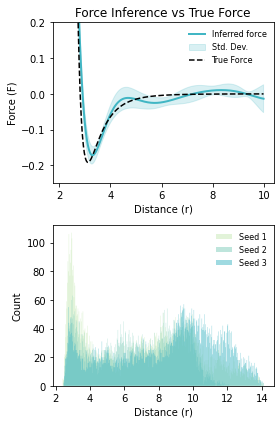

In [15]:
fig,ax = plt.subplots(2,1,figsize= (4,6))
NumBins = 400
bin_edges = np.linspace(R_N1*0.5, 10, NumBins + 1)
print(R_NT)
r_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
CCs = np.zeros((NumBasisFunctions,NumBins))
Rbins = 0.5 * (r_centers[:-1] + r_centers[1:])
FinferSeeds = []
for seed in range(3):
    FF = resultsFile[seed]['FF']  # Use the FF from the first run
    print("FF",FF)
    r_mod = resultsFile[seed]['r_mod']  # Use the r_mod from the
    Rhist = resultsFile[seed]['Rhist']  # Use the Rhist from the first run
    Bm05 = resultsFile[seed]['Bm05']  # Use the Bm05 from the first run
    TruForce = np.zeros((NumBins))
    for k, r in enumerate(r_centers):
        b = laguerre_polynomialsExp(r,NumBasisFunctions,r_mod)
        c = Bm05 @ b
        CCs[:,k] = c
        TruForce[k] = soft_lj_force(r, epsilon, sigma, rcut_inf, lambda_param)/gamma
        
    Finfer = FF.dot(CCs)
    
    FinferSeeds.append(Finfer[0,:-1])
    ax[1].hist(Rhist, bins=NumBins,  alpha=0.5, color=clrs[seed], label='Seed '+str(seed+1),histtype='stepfilled')

FinferAv = np.mean(FinferSeeds, axis=0)
FinferStd = np.std(FinferSeeds, axis=0)  
ax[0].plot(Rbins, FinferAv, marker='', alpha=1, ms=2, 
            color=clrs[2], linestyle='-',linewidth = 2,label = 'Inferred force')
ax[0].fill_between(Rbins, FinferAv - FinferStd, FinferAv + FinferStd,
                  color=clrs[2], alpha=0.2, label='Std. Dev.')
ax[0].plot(Rbins, -TruForce[:-1], color='black', linestyle='--', label='True Force')
ax[1].legend(frameon=False, fontsize=8)
ax[0].legend(frameon=False, fontsize=8)
ax[0].set_ylim(-0.25, 0.2)
ax[0].set_xlabel('Distance (r)')
ax[0].set_ylabel('Force (F)')
ax[0].set_title('Force Inference vs True Force')

ax[1].set_xlabel('Distance (r)')
ax[1].set_ylabel('Count')
fig.tight_layout()
# plotting the true force


In [242]:
## Standard Parameters
for seed in range(3):
    epsilon = 2.0 #0.5 #0.5
    sigma = 2.5 #+ee*0.5
    lambda_param = 1.0
    use_harmonic_trap = False # Set to False to disable the trap
    kappa = 4.  # Spring constant for the harmonic trap
    Center = np.array([0,0]) #Center of harmonic trap
    pair_interactions = True # Set to True to enable Lennard-Jones pair interactions
    num_particles = 10
    box_size = 20.0  # Box is a cube of size box_size x box_size
    temperature = 1.0 #0.2 #0.2  # Temperature (k_B * T)
    gamma = 10.0  # Friction coefficient
    dt = 0.01  # Time step
    frame = 10
    num_steps = 10000 #Number of simulation steps
    equilibration_steps = 2000 #Steps to equilibrate
    rcut=sigma*2+1
    name = "outputSig"+str(sigma)+"N"+str(num_particles)+"lambda"+str(lambda_param)+"seed"+str(seed)+".xyz"
    ## running the simulation:
    OD_MD_SimulationLJPairs(num_particles,box_size,kappa,temperature,gamma,dt,num_steps,equilibration_steps,frame,use_harmonic_trap,name,Center,epsilon,sigma,rcut,lambda_param)

Step 0/12000
Step 1000/12000
Step 2000/12000
Step 3000/12000
Step 4000/12000
Step 5000/12000
Step 6000/12000
Step 7000/12000
Step 8000/12000
Step 9000/12000
Step 10000/12000
Step 11000/12000
Simulation completed. Output written to outputSig2.5N10lambda1.0seed0.xyz
Minimum force -1.9171434048228742for params eps2.0 sig2.5 rc6.0
Step 0/12000
Step 1000/12000
Step 2000/12000
Step 3000/12000
Step 4000/12000
Step 5000/12000
Step 6000/12000
Step 7000/12000
Step 8000/12000
Step 9000/12000
Step 10000/12000
Step 11000/12000
Simulation completed. Output written to outputSig2.5N10lambda1.0seed1.xyz
Minimum force -1.9171432242246382for params eps2.0 sig2.5 rc6.0
Step 0/12000
Step 1000/12000
Step 2000/12000
Step 3000/12000
Step 4000/12000
Step 5000/12000
Step 6000/12000
Step 7000/12000
Step 8000/12000
Step 9000/12000
Step 10000/12000
Step 11000/12000
Simulation completed. Output written to outputSig2.5N10lambda1.0seed2.xyz
Minimum force -1.9171421172589496for params eps2.0 sig2.5 rc6.0


In [252]:
labels = ["no skip", "skip 2","skip 5"]
skips = [1]
resultsFile10 = []

for seed in range(3):
    name = "outputSig"+str(sigma)+"N"+str(num_particles)+"lambda"+str(lambda_param)+"seed"+str(seed)+".xyz"
    df_atoms = parse_lammps_xyz(datadir + name)
    L_x, L_y = box_size, box_size
    if df_atoms.isnull().values.any():
        print("DataFrame contains NaN values. Please check the input data.")
        continue
    R_NT,R_N1,R_mode,AvNN = Get_Distance_Quantities(df_atoms,L_x,L_y)
    NumAtoms = np.max(df_atoms.id)
    print("calculating forces ...")
    NumBasisFunctions = 10 #10 #*(ee+1)
    OnlyNN = False #True
    NumBins = 70
    bin_edges = np.linspace(R_N1*0.5, R_NT, NumBins + 1)
    rcut_yes = False
    rcut_inf = 1000 #R_NT #sigma+0.5
    r_mod = R_N1*2
    Finfer,CCs, FF, TruForce,Rhist,Bm05 = estmateforcesMultiPairLJ(NumBins,df_atoms,L_x,L_y,dt,gamma,sigma,kappa,Center,bin_edges,epsilon,NumBasisFunctions,OnlyNN,rcut_inf,rcut_yes,r_mod,lambda_param)
    #Bm05,FF,Rhist = estmateforcesMultiPairLJ(df_atoms,L_x,L_y,dt,NumBasisFunctions,OnlyNN,rcut_inf,rcut_yes,r_mod,lambda_param)
     # Store results in list with all relevant data
    resultsFile10.append({
        'Bm05': Bm05.copy(),
        'FF': FF.copy(),
        'Rhist': Rhist.copy(),
        'rcut_inf': rcut_inf,
        'rcut_yes': rcut_yes,
        'r_mod': r_mod,
        'label': labels[seed]
    })
    
    print(f"Completed run {seed+1}/3")

Processing timestep 2970/11990
Processing timestep 3960/11990
Processing timestep 4950/11990
Processing timestep 5940/11990
Processing timestep 6930/11990
Processing timestep 7920/11990
Processing timestep 8910/11990
Processing timestep 9900/11990
Processing timestep 10890/11990
Processing timestep 11880/11990
calculating forces ...
r_modulation 8.496862408861228
shape of B (10, 10)
dimension of FF_accum (1, 10)
dimension of CCs (10, 70)
Completed run 1/3
Processing timestep 2970/11990
Processing timestep 3960/11990
Processing timestep 4950/11990
Processing timestep 5940/11990
Processing timestep 6930/11990
Processing timestep 7920/11990
Processing timestep 8910/11990
Processing timestep 9900/11990
Processing timestep 10890/11990
Processing timestep 11880/11990
calculating forces ...
r_modulation 8.661097105101133
shape of B (10, 10)
dimension of FF_accum (1, 10)
dimension of CCs (10, 70)
Completed run 2/3
Processing timestep 2970/11990
Processing timestep 3960/11990
Processing timeste

7.275915101990592
FF [[ 0.06853989 -0.00168534 -0.03710335 -0.03486398 -0.02114117 -0.01794159
   0.00786038  0.00730143  0.00630027  0.01111882]]
FF [[ 0.06809746 -0.00226349 -0.02187705 -0.03644826 -0.0126319  -0.00496085
   0.01072218  0.00173862 -0.00050163  0.007893  ]]
FF [[ 0.08485204  0.00365749 -0.04292949 -0.04048501 -0.02377361 -0.01558218
   0.01033254 -0.00262001  0.00542868  0.00344882]]
number of particles 10


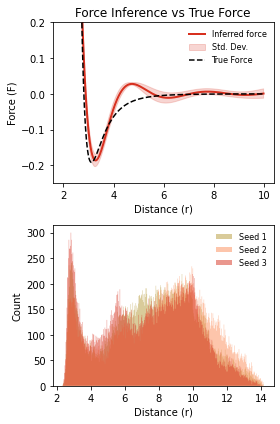

In [258]:
fig,ax = plt.subplots(2,1,figsize= (4,6))
NumBins = 400
bin_edges = np.linspace(R_N1*0.5, 10, NumBins + 1)
print(R_NT)
r_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
CCs = np.zeros((NumBasisFunctions,NumBins))
Rbins = 0.5 * (r_centers[:-1] + r_centers[1:])
FinferSeeds = []
for seed in range(3):
    FF = resultsFile10[seed]['FF']  # Use the FF from the first run
    print("FF",FF)
    r_mod = resultsFile10[seed]['r_mod']  # Use the r_mod from the
    Rhist = resultsFile10[seed]['Rhist']  # Use the Rhist from the first run
    Bm05 = resultsFile10[seed]['Bm05']  # Use the Bm05 from the first run
    TruForce = np.zeros((NumBins))
    for k, r in enumerate(r_centers):
        b = laguerre_polynomialsExp(r,NumBasisFunctions,r_mod)
        c = Bm05 @ b
        CCs[:,k] = c
        TruForce[k] = soft_lj_force(r, epsilon, sigma, rcut_inf, lambda_param)/gamma
        
    Finfer = FF.dot(CCs)
    
    FinferSeeds.append(Finfer[0,:-1])
    ax[1].hist(Rhist, bins=NumBins,  alpha=0.5, color=clrs2[seed], label='Seed '+str(seed+1),histtype='stepfilled')

FinferAv = np.mean(FinferSeeds, axis=0)
FinferStd = np.std(FinferSeeds, axis=0)  
ax[0].plot(Rbins, FinferAv, marker='', alpha=1, ms=2, 
            color=clrs2[2], linestyle='-',linewidth = 2,label = 'Inferred force')
ax[0].fill_between(Rbins, FinferAv - FinferStd, FinferAv + FinferStd,
                  color=clrs2[2], alpha=0.2, label='Std. Dev.')
ax[0].plot(Rbins, -TruForce[:-1], color='black', linestyle='--', label='True Force')
ax[1].legend(frameon=False, fontsize=8)
ax[0].legend(frameon=False, fontsize=8)
ax[0].set_ylim(-0.25, 0.2)
ax[0].set_xlabel('Distance (r)')
ax[0].set_ylabel('Force (F)')
ax[0].set_title('Force Inference vs True Force')

ax[1].set_xlabel('Distance (r)')
ax[1].set_ylabel('Count')
fig.tight_layout()
# plotting the true force
print("number of particles",num_particles)

In [16]:
## Standard Parameters
for seed in range(3):
    epsilon = 2.0 #0.5 #0.5
    sigma = 2.5 #+ee*0.5
    lambda_param = 1.0
    use_harmonic_trap = False # Set to False to disable the trap
    kappa = 4.  # Spring constant for the harmonic trap
    Center = np.array([0,0]) #Center of harmonic trap
    pair_interactions = True # Set to True to enable Lennard-Jones pair interactions
    num_particles = 20
    box_size = 20.0  # Box is a cube of size box_size x box_size
    temperature = 1.0 #0.2 #0.2  # Temperature (k_B * T)
    gamma = 10.0  # Friction coefficient
    dt = 0.01  # Time step
    frame = 10
    num_steps = 5000 #Number of simulation steps
    equilibration_steps = 1000 #Steps to equilibrate
    rcut=sigma*2+1
    name = "outputSig"+str(sigma)+"N"+str(num_particles)+"lambda"+str(lambda_param)+"seed"+str(seed)+".xyz"
    ## running the simulation:
    OD_MD_SimulationLJPairs(num_particles,box_size,kappa,temperature,gamma,dt,num_steps,equilibration_steps,frame,use_harmonic_trap,name,Center,epsilon,sigma,rcut,lambda_param)

Step 0/6000
Step 1000/6000
Step 2000/6000
Step 3000/6000
Step 4000/6000
Step 5000/6000
Simulation completed. Output written to outputSig2.5N20lambda1.0seed0.xyz
Minimum force -1.9171433822330906for params eps2.0 sig2.5 rc6.0
Step 0/6000
Step 1000/6000
Step 2000/6000
Step 3000/6000
Step 4000/6000
Step 5000/6000
Simulation completed. Output written to outputSig2.5N20lambda1.0seed1.xyz
Minimum force -1.9171432604981251for params eps2.0 sig2.5 rc6.0
Step 0/6000
Step 1000/6000
Step 2000/6000
Step 3000/6000
Step 4000/6000
Step 5000/6000
Simulation completed. Output written to outputSig2.5N20lambda1.0seed2.xyz
Minimum force -1.9171433684327122for params eps2.0 sig2.5 rc6.0


In [17]:
labels = ["no skip", "skip 2","skip 5"]
skips = [1]
resultsFile = []

for seed in range(3):
    name = "outputSig"+str(sigma)+"N"+str(num_particles)+"lambda"+str(lambda_param)+"seed"+str(seed)+".xyz"
    df_atoms = parse_lammps_xyz(datadir + name)
    L_x, L_y = box_size, box_size
    if df_atoms.isnull().values.any():
        print("DataFrame contains NaN values. Please check the input data.")
        continue
    R_NT,R_N1,R_mode,AvNN = Get_Distance_Quantities(df_atoms,L_x,L_y)
    NumAtoms = np.max(df_atoms.id)
    print("calculating forces ...")
    NumBasisFunctions = 10 #10 #*(ee+1)
    OnlyNN = False #True
    NumBins = 70
    bin_edges = np.linspace(R_N1*0.5, R_NT, NumBins + 1)
    rcut_yes = False
    rcut_inf = 1000 #R_NT #sigma+0.5
    r_mod = R_N1*2
    Finfer,CCs, FF, TruForce,Rhist,Bm05 = estmateforcesMultiPairLJ(NumBins,df_atoms,L_x,L_y,dt,gamma,sigma,kappa,Center,bin_edges,epsilon,NumBasisFunctions,OnlyNN,rcut_inf,rcut_yes,r_mod,lambda_param)
    #Bm05,FF,Rhist = estmateforcesMultiPairLJ(df_atoms,L_x,L_y,dt,NumBasisFunctions,OnlyNN,rcut_inf,rcut_yes,r_mod,lambda_param)
     # Store results in list with all relevant data
    resultsFile.append({
        'Bm05': Bm05.copy(),
        'FF': FF.copy(),
        'Rhist': Rhist.copy(),
        'rcut_inf': rcut_inf,
        'rcut_yes': rcut_yes,
        'r_mod': r_mod,
    })
    
    print(f"Completed run {seed+1}/3")

Processing timestep 1470/5990
Processing timestep 1960/5990
Processing timestep 2450/5990
Processing timestep 2940/5990
Processing timestep 3430/5990
Processing timestep 3920/5990
Processing timestep 4410/5990
Processing timestep 4900/5990
Processing timestep 5390/5990
Processing timestep 5880/5990
calculating forces ...
r_modulation 6.962601268184778
shape of B (10, 10)
dimension of FF_accum (1, 10)
dimension of CCs (10, 70)
Completed run 1/3
Processing timestep 1470/5990
Processing timestep 1960/5990
Processing timestep 2450/5990
Processing timestep 2940/5990
Processing timestep 3430/5990
Processing timestep 3920/5990
Processing timestep 4410/5990
Processing timestep 4900/5990
Processing timestep 5390/5990
Processing timestep 5880/5990
calculating forces ...
r_modulation 7.643012342025056
shape of B (10, 10)
dimension of FF_accum (1, 10)
dimension of CCs (10, 70)
Completed run 2/3
Processing timestep 1470/5990
Processing timestep 1960/5990
Processing timestep 2450/5990
Processing tim

7.897014507802859
FF [[ 0.08069197  0.00418534 -0.03317821 -0.03262952 -0.01865214 -0.01723776
   0.0086614  -0.00326559  0.00528519  0.00763039]]
FF [[ 0.06506104 -0.00259919 -0.03118106 -0.03592877 -0.01313666 -0.01642362
   0.00935348 -0.00295034  0.00419939  0.00596705]]
FF [[ 0.07505622 -0.00160202 -0.03418922 -0.03715977 -0.02044873 -0.023561
   0.01007219 -0.00478106  0.00647557  0.00549737]]
number of particles 20


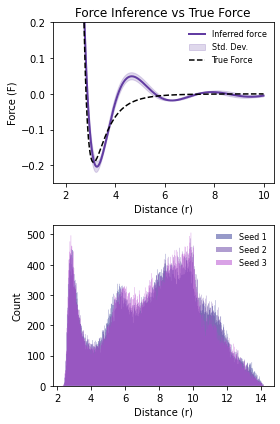

In [19]:
fig,ax = plt.subplots(2,1,figsize= (4,6))
NumBins = 400
bin_edges = np.linspace(R_N1*0.5, 10, NumBins + 1)
print(R_NT)
r_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
CCs = np.zeros((NumBasisFunctions,NumBins))
Rbins = 0.5 * (r_centers[:-1] + r_centers[1:])
FinferSeeds = []
for seed in range(3):
    FF = resultsFile[seed]['FF']  # Use the FF from the first run
    print("FF",FF)
    r_mod = resultsFile[seed]['r_mod']  # Use the r_mod from the
    Rhist = resultsFile[seed]['Rhist']  # Use the Rhist from the first run
    Bm05 = resultsFile[seed]['Bm05']  # Use the Bm05 from the first run
    TruForce = np.zeros((NumBins))
    for k, r in enumerate(r_centers):
        b = laguerre_polynomialsExp(r,NumBasisFunctions,r_mod)
        c = Bm05 @ b
        CCs[:,k] = c
        TruForce[k] = soft_lj_force(r, epsilon, sigma, rcut_inf, lambda_param)/gamma
        
    Finfer = FF.dot(CCs)
    
    FinferSeeds.append(Finfer[0,:-1])
    ax[1].hist(Rhist, bins=NumBins,  alpha=0.5, color=clrs3[seed], label='Seed '+str(seed+1),histtype='stepfilled')

FinferAv = np.mean(FinferSeeds, axis=0)
FinferStd = np.std(FinferSeeds, axis=0)  
ax[0].plot(Rbins, FinferAv, marker='', alpha=1, ms=2, 
            color=clrs3[1], linestyle='-',linewidth = 2,label = 'Inferred force')
ax[0].fill_between(Rbins, FinferAv - FinferStd, FinferAv + FinferStd,
                  color=clrs3[1], alpha=0.2, label='Std. Dev.')
ax[0].plot(Rbins, -TruForce[:-1], color='black', linestyle='--', label='True Force')
ax[1].legend(frameon=False, fontsize=8)
ax[0].legend(frameon=False, fontsize=8)
ax[0].set_ylim(-0.25, 0.2)
ax[0].set_xlabel('Distance (r)')
ax[0].set_ylabel('Force (F)')
ax[0].set_title('Force Inference vs True Force')

ax[1].set_xlabel('Distance (r)')
ax[1].set_ylabel('Count')
fig.tight_layout()
# plotting the true force
print("number of particles",num_particles)